# ENGE707 — Staged CNN (Cat/Dog → Feature → Combined)

**Goal:** Compare our existing padded CNN (**76.78% validation accuracy**) with a model trained in stages:

1. Learn **Cat versus Dog** from all training images.
2. Freeze the visual backbone and learn **Eye / Face / Mouth / Nose**.
3. Unfreeze the backbone and **fine-tune both predictions together** to produce eight classes.

Uses the **same 80/20 split** (`random_state=42`), proportional **128 × 128 padding**, batch **64**, **2 workers**, and mixed precision. Nothing changes the original CSV or images. **100% species accuracy is not guaranteed**. Staged training takes more total epochs than the old baseline, so differences are not a compute-matched architecture comparison.

### 1 — Setup and data split

In [1]:
from pathlib import Path
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

ROOT = Path.cwd()  # Open this notebook from your Kaggle project folder
TRAIN_DIR = ROOT / "train" / "train"
assert TRAIN_DIR.is_dir(), f"Images not found: {TRAIN_DIR}"

df = pd.read_csv(ROOT / "train_labels.csv", dtype={"image_id": str})
class_names = sorted(df["class"].unique())
species_names = ["Cat", "Dog"]
feature_names = ["Eye", "Face", "Mouth", "Nose"]
assert class_names == [s + f for s in species_names for f in feature_names]

train_data, val_data = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["class"]
)
train_data, val_data = train_data.reset_index(drop=True), val_data.reset_index(drop=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH, WORKERS = 64, 2
EPOCHS_SPECIES, EPOCHS_FEATURE, EPOCHS_JOINT = 8, 5, 8
print("Train:", len(train_data), "| Validation:", len(val_data))
print("Classes:", class_names)
print("Device:", device, "| Batch:", BATCH, "| CPU workers:", WORKERS)

Train: 50928 | Validation: 12732
Classes: ['CatEye', 'CatFace', 'CatMouth', 'CatNose', 'DogEye', 'DogFace', 'DogMouth', 'DogNose']
Device: cuda | Batch: 64 | CPU workers: 2


### 2 — Dataset and DataLoaders

The notebook writes one small Python helper file so **Windows/Jupyter multiprocessing** works correctly. Keep it beside the notebook.

In [2]:
%%writefile staged_dataset.py
from pathlib import Path
from PIL import Image, ImageOps
from torch.utils.data import Dataset
from torchvision.transforms.functional import to_tensor

FEATURES = {"Eye": 0, "Face": 1, "Mouth": 2, "Nose": 3}

class StagedImages(Dataset):
    def __init__(self, data, directory, mode="pad"):
        self.samples = []
        for image_id, label in data[["image_id", "class"]].itertuples(index=False, name=None):
            species = 0 if label.startswith("Cat") else 1
            feature = FEATURES[label[3:]]
            self.samples.append((Path(directory) / f"{image_id}.jpg", species, feature))
        self.mode = mode

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, species, feature = self.samples[i]
        with Image.open(path) as img:
            img = img.convert("RGB")
            if self.mode == "pad":
                img = ImageOps.pad(img, (128, 128), method=Image.Resampling.BILINEAR,
                                   color=(114, 114, 114))
            else:  # Previous stretched baseline, if its checkpoint exists
                img = img.resize((128, 128), Image.Resampling.BILINEAR)
            x = to_tensor(img)
        return x, species, feature, species * 4 + feature

Writing staged_dataset.py


In [3]:
from staged_dataset import StagedImages

def make_loader(data, shuffle=False, mode="pad"):
    return DataLoader(
        StagedImages(data, TRAIN_DIR, mode=mode), batch_size=BATCH, shuffle=shuffle,
        num_workers=WORKERS, pin_memory=(device.type == "cuda"),
        persistent_workers=False, prefetch_factor=1
    )

train_loader = make_loader(train_data, shuffle=True)
val_loader = make_loader(val_data)
x, species, feature, label8 = next(iter(train_loader))
print("Image batch:", tuple(x.shape))
print("Species targets:", species_names, "| Feature targets:", feature_names)
print("Eight-class targets:", class_names)

Image batch: (64, 3, 128, 128)
Species targets: ['Cat', 'Dog'] | Feature targets: ['Eye', 'Face', 'Mouth', 'Nose']
Eight-class targets: ['CatEye', 'CatFace', 'CatMouth', 'CatNose', 'DogEye', 'DogFace', 'DogMouth', 'DogNose']


### 3 — CNN with two classification heads

The shared convolutional **backbone** learns visual features. Each head makes a separate prediction; `Cat + Nose` becomes `CatNose`. This reuses the same three-convolution architecture as our earlier baseline.

In [4]:
class StagedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.species_head = nn.Linear(128, 2)
        self.feature_head = nn.Linear(128, 4)

    def forward(self, x):
        z = self.encoder(x).flatten(1)
        return self.species_head(z), self.feature_head(z)

model = StagedCNN().to(device)
criterion = nn.CrossEntropyLoss()
CHECKPOINTS = ROOT / "staged_checkpoints"
CHECKPOINTS.mkdir(exist_ok=True)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

Trainable parameters: 94022


### 4 — Shared training and evaluation functions

In [5]:
def evaluate(net, loader):
    net.eval()
    species_true, feature_true, class_true = [], [], []
    species_pred, feature_pred, class_pred = [], [], []
    with torch.inference_mode():
        for images, s, f, y in loader:
            images = images.to(device, non_blocking=True)
            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                slogits, flogits = net(images)
            sp, fp = slogits.argmax(1).cpu(), flogits.argmax(1).cpu()
            species_true.extend(s.tolist()); feature_true.extend(f.tolist()); class_true.extend(y.tolist())
            species_pred.extend(sp.tolist()); feature_pred.extend(fp.tolist())
            class_pred.extend((sp * 4 + fp).tolist())
    return {
        "species_acc": accuracy_score(species_true, species_pred),
        "feature_acc": accuracy_score(feature_true, feature_pred),
        "class_acc": accuracy_score(class_true, class_pred),
        "macro_f1": f1_score(class_true, class_pred, average="macro"),
        "true": class_true, "pred": class_pred,
    }

history = []

def train_stage(stage, epochs, lr):
    # species: train backbone + species head
    # feature: freeze backbone/species head; train only feature head
    # joint: fine-tune backbone and both heads together
    model.encoder.requires_grad_(stage != "feature")
    model.species_head.requires_grad_(stage != "feature")
    model.feature_head.requires_grad_(stage != "species")
    opt = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)
    scaler = GradScaler("cuda", enabled=device.type == "cuda")
    metric = {"species": "species_acc", "feature": "feature_acc", "joint": "class_acc"}[stage]
    checkpoint = CHECKPOINTS / f"best_{stage}.pt"
    best = -1

    for epoch in range(1, epochs + 1):
        start = time.perf_counter()
        model.train()
        if stage == "feature": model.encoder.eval()
        total_loss = 0.0
        for images, s, f, _ in train_loader:
            images = images.to(device, non_blocking=True)
            s = s.to(device, non_blocking=True); f = f.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                slogits, flogits = model(images)
                if stage == "species": loss = criterion(slogits, s)
                elif stage == "feature": loss = criterion(flogits, f)
                else: loss = criterion(slogits, s) + criterion(flogits, f)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            total_loss += loss.item() * len(s)

        result = evaluate(model, val_loader)
        if result[metric] > best:
            best = result[metric]
            torch.save(model.state_dict(), checkpoint)
        if device.type == "cuda": torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        history.append({"stage": stage, "epoch": epoch, "loss": total_loss / len(train_data),
                        "species_acc": result["species_acc"], "feature_acc": result["feature_acc"],
                        "class_acc": result["class_acc"], "seconds": elapsed})
        print(f"{stage:7} {epoch:2}/{epochs} | Cat/Dog {result['species_acc']:.2%} | "
              f"Feature {result['feature_acc']:.2%} | 8-class {result['class_acc']:.2%} | {elapsed:.1f}s")

    model.load_state_dict(torch.load(checkpoint, map_location=device, weights_only=True))
    result = evaluate(model, val_loader)
    print(f"Best {stage} checkpoint | Cat/Dog {result['species_acc']:.2%} | "
          f"Feature {result['feature_acc']:.2%} | 8-class {result['class_acc']:.2%}")
    return result

### 5 — Stage 1: Cat or Dog

Train **only** the backbone and Cat/Dog head. We measure validation accuracy rather than attempting to force training accuracy to 100%.

In [6]:
stage1 = train_stage("species", EPOCHS_SPECIES, lr=0.001)

species  1/8 | Cat/Dog 74.72% | Feature 21.16% | 8-class 14.78% | 31.0s
species  2/8 | Cat/Dog 81.36% | Feature 21.36% | 8-class 16.69% | 30.5s
species  3/8 | Cat/Dog 85.63% | Feature 21.09% | 8-class 18.02% | 30.4s
species  4/8 | Cat/Dog 87.64% | Feature 21.06% | 8-class 18.84% | 30.2s
species  5/8 | Cat/Dog 87.95% | Feature 20.66% | 8-class 18.87% | 30.3s
species  6/8 | Cat/Dog 89.90% | Feature 20.53% | 8-class 19.10% | 30.4s
species  7/8 | Cat/Dog 90.59% | Feature 20.15% | 8-class 18.65% | 30.5s
species  8/8 | Cat/Dog 90.31% | Feature 20.45% | 8-class 18.83% | 30.6s
Best species checkpoint | Cat/Dog 90.59% | Feature 20.15% | 8-class 18.65%


### 6 — Stage 2: Eye / Face / Mouth / Nose

Keep the species-trained backbone **frozen**. Add knowledge using the second head without changing what Stage 1 learned.

In [7]:
stage2 = train_stage("feature", EPOCHS_FEATURE, lr=0.001)

feature  1/5 | Cat/Dog 90.59% | Feature 65.15% | 8-class 59.70% | 30.8s
feature  2/5 | Cat/Dog 90.59% | Feature 68.47% | 8-class 62.80% | 30.4s
feature  3/5 | Cat/Dog 90.59% | Feature 68.33% | 8-class 62.50% | 30.4s
feature  4/5 | Cat/Dog 90.59% | Feature 71.30% | 8-class 65.50% | 30.4s
feature  5/5 | Cat/Dog 90.59% | Feature 71.50% | 8-class 65.79% | 30.4s
Best feature checkpoint | Cat/Dog 90.59% | Feature 71.50% | 8-class 65.79%


### 7 — Stage 3: Joint fine-tuning

Unfreeze everything and optimise both heads. The final class is the species prediction combined with the feature prediction.

In [8]:
stage3 = train_stage("joint", EPOCHS_JOINT, lr=0.0003)

joint    1/8 | Cat/Dog 90.29% | Feature 78.93% | 8-class 72.46% | 30.5s
joint    2/8 | Cat/Dog 91.27% | Feature 82.13% | 8-class 75.92% | 30.6s
joint    3/8 | Cat/Dog 91.79% | Feature 82.30% | 8-class 76.42% | 30.3s
joint    4/8 | Cat/Dog 92.10% | Feature 84.50% | 8-class 78.64% | 30.3s
joint    5/8 | Cat/Dog 91.96% | Feature 85.82% | 8-class 79.56% | 30.5s
joint    6/8 | Cat/Dog 92.05% | Feature 86.94% | 8-class 80.79% | 30.6s
joint    7/8 | Cat/Dog 91.86% | Feature 87.35% | 8-class 80.98% | 30.5s
joint    8/8 | Cat/Dog 92.07% | Feature 87.61% | 8-class 81.50% | 30.5s
Best joint checkpoint | Cat/Dog 92.07% | Feature 87.61% | 8-class 81.50%


### 8 — Compare stages and original CNN

If your original checkpoints (`cnn_128_padded.pt`, `cnn_128_fp16_batch64.pt`) are in this folder, they are **evaluated on the same validation split**. Otherwise the earlier accuracy values are shown as *reported reference only*.

In [9]:
# Architecture used by our previous eight-class CNN
class PreviousCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 8)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

def evaluate_previous(path, mode):
    if not path.exists(): return None
    net = PreviousCNN().to(device)
    net.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    net.eval()
    true, pred = [], []
    with torch.inference_mode():
        for images, _, _, target in make_loader(val_data, mode=mode):
            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                logits = net(images.to(device, non_blocking=True))
            true.extend(target.tolist()); pred.extend(logits.argmax(1).cpu().tolist())
    return {
        "species_acc": accuracy_score(np.array(true) // 4, np.array(pred) // 4),
        "feature_acc": accuracy_score(np.array(true) % 4, np.array(pred) % 4),
        "class_acc": accuracy_score(true, pred),
        "macro_f1": f1_score(true, pred, average="macro"),
        "true": true, "pred": pred
    }

fixed = evaluate_previous(ROOT / "cnn_128_fp16_batch64.pt", "stretch")
padded = evaluate_previous(ROOT / "cnn_128_padded.pt", "pad")

rows = []
for name, r in [("Stage 1: Species", stage1), ("Stage 2: Feature", stage2),
                ("Stage 3: Joint", stage3), ("Previous: Stretched", fixed),
                ("Previous: Padded", padded)]:
    if r is None:
        if "Stretched" in name: rows.append([name + " (reported)", None, None, 72.54, None])
        elif "Padded" in name: rows.append([name + " (reported)", None, None, 76.78, 0.778])
        continue
    if name == "Stage 1: Species":
        rows.append([name, 100*r["species_acc"], None, None, None])
    else:
        rows.append([name, 100*r["species_acc"], 100*r["feature_acc"],
                     100*r["class_acc"], r["macro_f1"]])

comparison = pd.DataFrame(rows, columns=["Model / stage", "Cat/Dog %", "Feature %", "8-class %", "Macro F1"])
print(comparison.round(3).to_string(index=False))
print("Training budgets differ: staged CNN uses more total epochs than the previous CNN.")

      Model / stage  Cat/Dog %  Feature %  8-class %  Macro F1
   Stage 1: Species     90.591        NaN        NaN       NaN
   Stage 2: Feature     90.591     71.505     65.787     0.645
     Stage 3: Joint     92.067     87.614     81.503     0.819
Previous: Stretched     87.771     78.880     72.542     0.716
   Previous: Padded     87.331     83.216     76.775     0.778
Training budgets differ: staged CNN uses more total epochs than the previous CNN.


### 9 — Final errors and label ambiguity

Inspect the top confusion pairs on **untouched validation labels**. The notebook does **not** automatically rewrite CatNose or CatMouth labels: questionable examples need human review against a consistent labelling rule.

FINAL STAGED MODEL — EIGHT CLASSES
              precision    recall  f1-score   support

      CatEye      0.811     0.860     0.835      2777
     CatFace      0.890     0.927     0.908      1388
    CatMouth      0.957     0.996     0.976      1388
     CatNose      0.732     0.731     0.732      1389
      DogEye      0.785     0.630     0.699      2316
     DogFace      0.749     0.821     0.784      1158
    DogMouth      0.989     0.974     0.981      1158
     DogNose      0.618     0.662     0.639      1158

    accuracy                          0.815     12732
   macro avg      0.816     0.825     0.819     12732
weighted avg      0.815     0.815     0.813     12732


Top ten confusions:
actual   predicted
DogEye   CatEye       309
         DogNose      283
CatNose  CatEye       216
DogNose  DogEye       171
CatEye   CatNose      168
         DogEye       161
DogEye   DogFace      154
DogNose  DogFace      113
DogEye   CatNose       99
CatNose  DogNose       85
dtype: int64


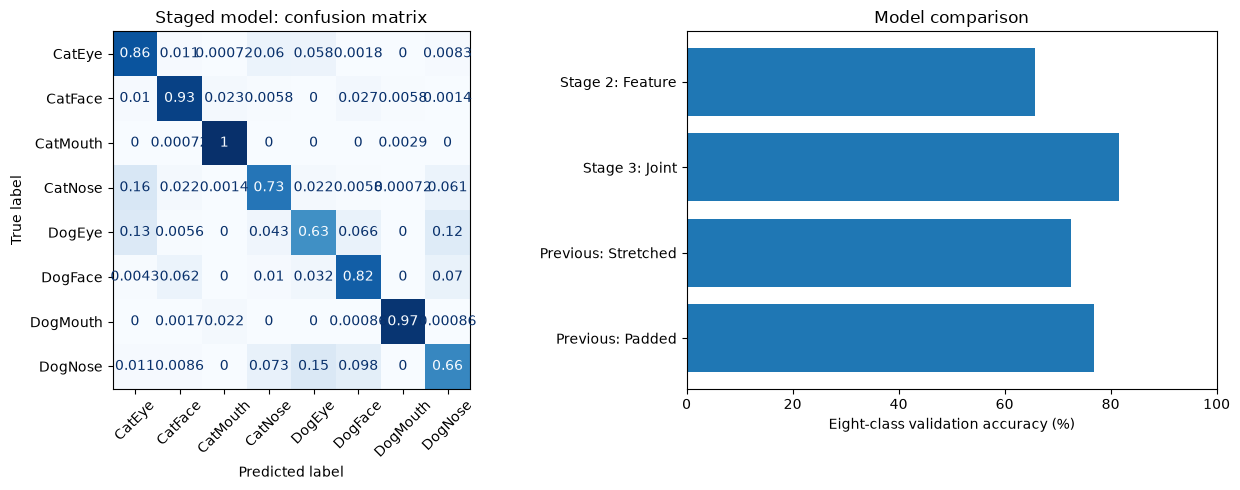

In [10]:
print("FINAL STAGED MODEL — EIGHT CLASSES")
print(classification_report(stage3["true"], stage3["pred"], target_names=class_names, digits=3))

pairs = pd.DataFrame({"actual": [class_names[i] for i in stage3["true"]],
                      "predicted": [class_names[i] for i in stage3["pred"]]})
wrong = pairs[pairs["actual"] != pairs["predicted"]]
print("\nTop ten confusions:")
print(wrong.groupby(["actual", "predicted"]).size().sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    stage3["true"], stage3["pred"], display_labels=class_names,
    normalize="true", xticks_rotation=45, cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Staged model: confusion matrix")
plot_df = comparison.dropna(subset=["8-class %"])
axes[1].barh(plot_df["Model / stage"], plot_df["8-class %"])
axes[1].set(xlabel="Eight-class validation accuracy (%)", title="Model comparison", xlim=(0, 100))
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Interpretation:** If Cat/Dog accuracy is high but eight-class accuracy remains low, feature recognition or inconsistent feature labels are likely major limitations. If Cat/Dog is weak, improve the species backbone (e.g. pretrained ResNet-18). **Do not relabel validation images to improve the score.**

### 10 — Look at real classification errors (optional)

Display examples from the three largest confusion pairs. Each image retains its original resolution. **Do not automatically relabel images based on model predictions.**

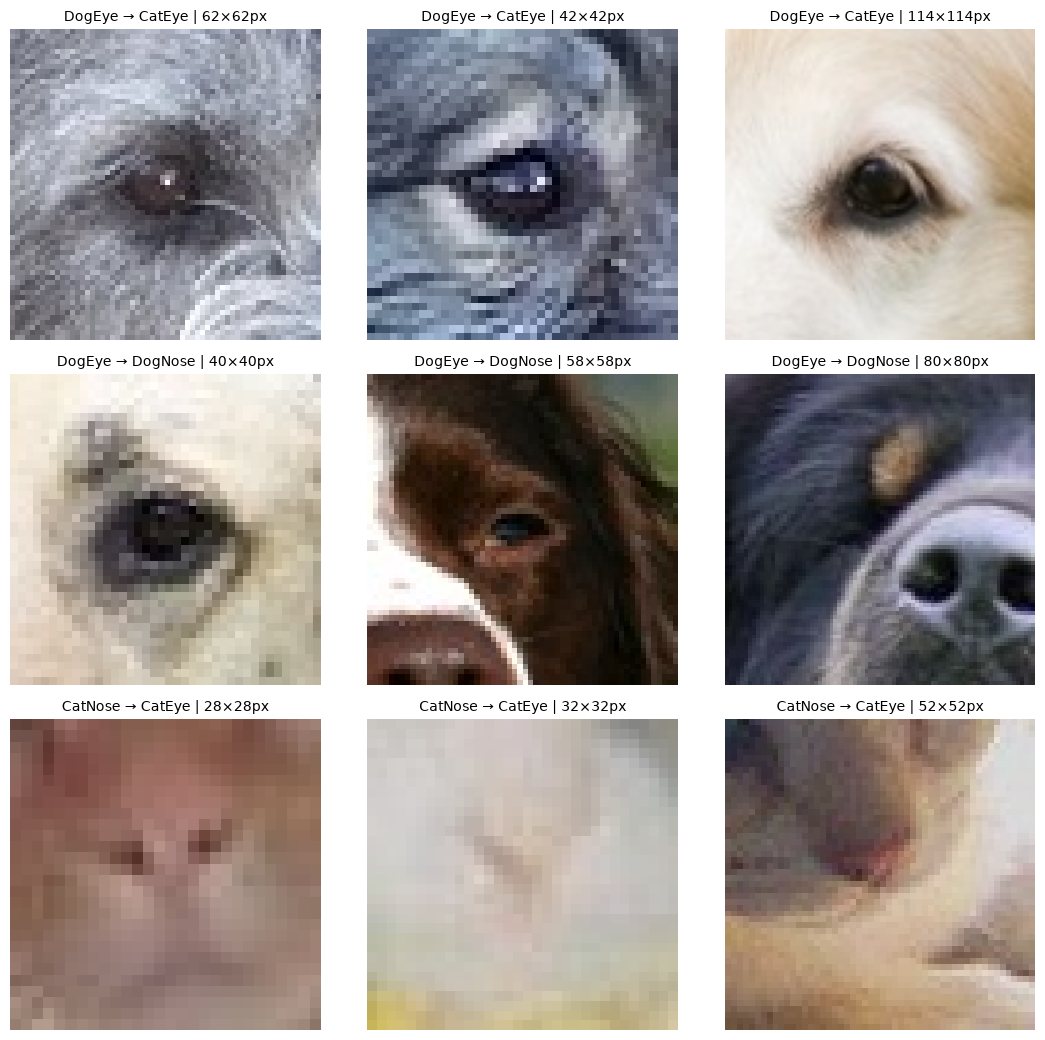

In [11]:
# Match predictions to validation IDs (validation loader is not shuffled)
audit = val_data.copy()
audit["predicted"] = [class_names[i] for i in stage3["pred"]]
audit["incorrect"] = audit["class"] != audit["predicted"]

mistakes = audit[audit["incorrect"]]
top_pairs = (mistakes.groupby(["class", "predicted"])
             .size().sort_values(ascending=False).head(3).index)

fig, axes = plt.subplots(len(top_pairs), 3, figsize=(11, 3.5 * len(top_pairs)))
for row, (actual, predicted) in enumerate(top_pairs):
    subset = mistakes[(mistakes["class"] == actual) &
                      (mistakes["predicted"] == predicted)]
    for col, (_, example) in enumerate(subset.sample(n=min(3, len(subset)), random_state=42).iterrows()):
        with Image.open(TRAIN_DIR / f"{example['image_id']}.jpg") as img:
            w, h = img.size
            axes[row, col].imshow(img)
        axes[row, col].set_title(f"{actual} → {predicted} | {w}×{h}px", fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout(); plt.show()

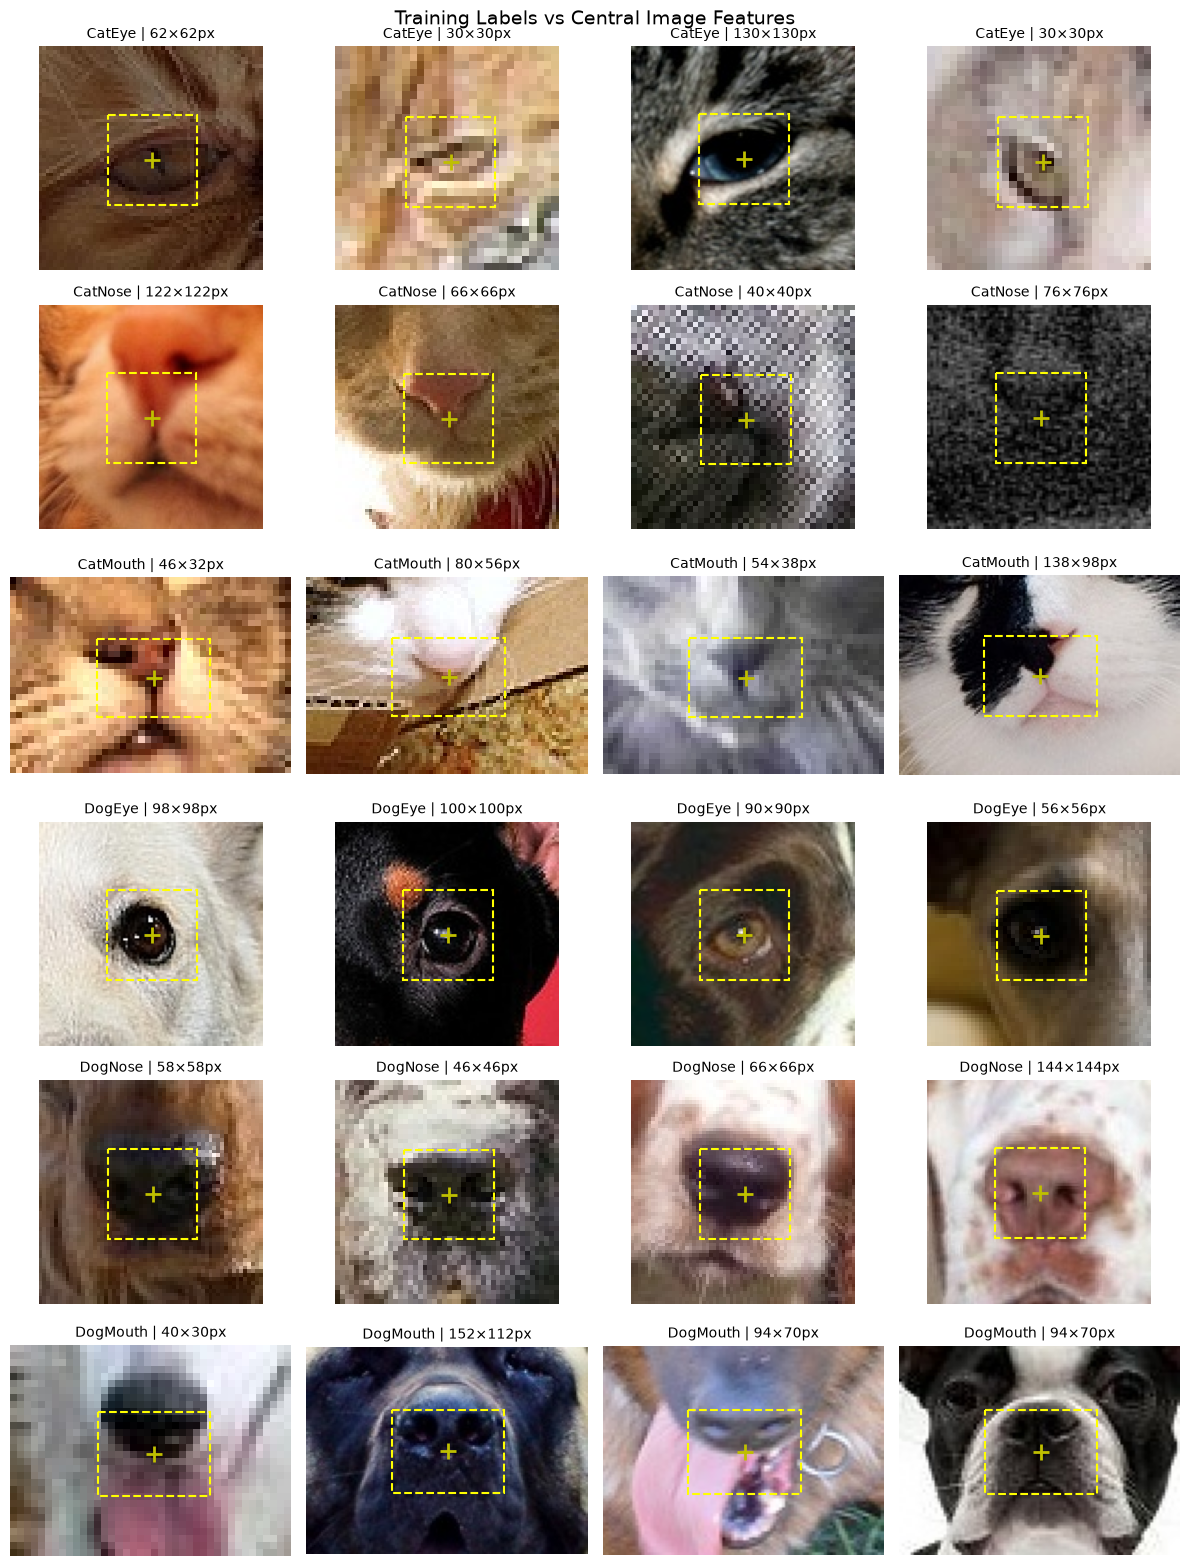

In [12]:
from matplotlib.patches import Rectangle

classes = ["CatEye", "CatNose", "CatMouth",
           "DogEye", "DogNose", "DogMouth"]

# Four random training images from each class
samples = (
    train_data[train_data["class"].isin(classes)]
    .groupby("class")
    .sample(n=4, random_state=42)
)

fig, axes = plt.subplots(6, 4, figsize=(12, 16))

for row, cls in enumerate(classes):
    subset = samples[samples["class"] == cls]

    for col, (_, item) in enumerate(subset.iterrows()):
        path = TRAIN_DIR / f"{item['image_id']}.jpg"

        with Image.open(path) as img:
            w, h = img.size
            axes[row, col].imshow(img)

        # Mark the centre and central 40% of the image
        axes[row, col].plot(w/2, h/2, "y+", markersize=12, markeredgewidth=2)
        axes[row, col].add_patch(Rectangle(
            (w*0.3, h*0.3), w*0.4, h*0.4,
            fill=False, edgecolor="yellow", linestyle="--", linewidth=1.5
        ))

        axes[row, col].set_title(f"{cls} | {w}×{h}px", fontsize=10)
        axes[row, col].axis("off")

plt.suptitle("Training Labels vs Central Image Features", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
from torch.utils.data import Dataset
from torchvision.transforms.functional import resized_crop, InterpolationMode

class CenterView(Dataset):
    def __init__(self, base, keep):
        self.base, self.keep = base, keep

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        image, species, feature, label = self.base[i]
        size = round(128 * self.keep)
        offset = (128 - size) // 2
        image = resized_crop(
            image, offset, offset, size, size,
            [128, 128], InterpolationMode.BILINEAR
        )
        return image, species, feature, label

# Test the existing staged model without retraining
base = StagedImages(val_data, TRAIN_DIR, mode="pad")
results = []

for keep in [1.0, 0.85, 0.70]:
    loader = DataLoader(CenterView(base, keep), batch_size=64, shuffle=False, num_workers=0)
    r = evaluate(model, loader)

    row = {"Centre retained": f"{keep:.0%}",
           "Cat/Dog %": r["species_acc"] * 100,
           "Feature %": r["feature_acc"] * 100,
           "8-class %": r["class_acc"] * 100}

    true, pred = np.array(r["true"]), np.array(r["pred"])
    for i, name in enumerate(class_names):
        row[name] = (pred[true == i] == i).mean() * 100

    results.append(row)

display(pd.DataFrame(results).set_index("Centre retained").round(2))

,Cat/Dog %,Feature %,8-class %,CatEye,CatFace,CatMouth,CatNose,DogEye,DogFace,DogMouth,DogNose
Centre retained,,,,,,,,,,,
100%,92.07,87.61,81.50,85.99,92.72,99.64,73.07,62.95,82.12,97.41,66.23
85%,89.15,65.62,59.35,84.52,67.29,13.11,71.06,66.41,62.44,0.35,72.71
70%,87.01,55.73,48.70,78.86,27.52,0.50,63.86,61.53,40.24,0.00,72.80


In [14]:
# Check original image geometry by class
records = []

for image_id, label in train_data[["image_id", "class"]].itertuples(index=False, name=None):
    with Image.open(TRAIN_DIR / f"{image_id}.jpg") as img:
        w, h = img.size

    records.append((label, w / h, w == h))

ratio_df = pd.DataFrame(
    records, columns=["class", "aspect_ratio", "square"]
)

summary = ratio_df.groupby("class").agg(
    images=("aspect_ratio", "size"),
    median_ratio=("aspect_ratio", "median"),
    square_pct=("square", lambda x: x.mean() * 100),
    wide_pct=("aspect_ratio", lambda x: (x > 1.25).mean() * 100)
)

print("Original image geometry by class:")
print(summary.round(2))

Original image geometry by class:
          images  median_ratio  square_pct  wide_pct
class                                               
CatEye     11107          1.00       99.90      0.02
CatFace     5554          0.83        0.59      3.17
CatMouth    5554          1.42        0.00     99.95
CatNose     5553          1.00       98.90      0.25
DogEye      9264          1.00       99.96      0.00
DogFace     4632          1.00       61.92      0.00
DogMouth    4632          1.35        0.02     99.83
DogNose     4632          1.00       99.91      0.00


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Read original image dimensions from validation data
geometry = val_data.reset_index(drop=True).copy()

ratios = []
for image_id in geometry["image_id"]:
    with Image.open(TRAIN_DIR / f"{image_id}.jpg") as img:
        w, h = img.size
        ratios.append(w / h)

geometry["ratio"] = ratios

# Binary task: Mouth versus Not Mouth
actual = geometry["class"].str.endswith("Mouth")
predicted = geometry["ratio"] > 1.25

print("Geometry-only mouth detection:")
print(classification_report(
    actual, predicted,
    target_names=["Not Mouth", "Mouth"],
    digits=3
))

print("Confusion matrix:")
print(confusion_matrix(actual, predicted))

print("\nWide images by actual class (%):")
print((geometry.groupby("class")["ratio"]
       .apply(lambda x: (x > 1.25).mean() * 100)).round(2))

Geometry-only mouth detection:
              precision    recall  f1-score   support

   Not Mouth      1.000     0.996     0.998     10186
       Mouth      0.984     0.999     0.991      2546

    accuracy                          0.997     12732
   macro avg      0.992     0.997     0.995     12732
weighted avg      0.997     0.997     0.997     12732

Confusion matrix:
[[10145    41]
 [    3  2543]]

Wide images by actual class (%):
class
CatEye       0.04
CatFace      2.74
CatMouth    99.93
CatNose      0.14
DogEye       0.00
DogFace      0.00
DogMouth    99.83
DogNose      0.00
Name: ratio, dtype: float64


Exceptions by class:
class
CatFace     38
CatNose      2
DogMouth     2
CatEye       1
CatMouth     1
Name: count, dtype: int64


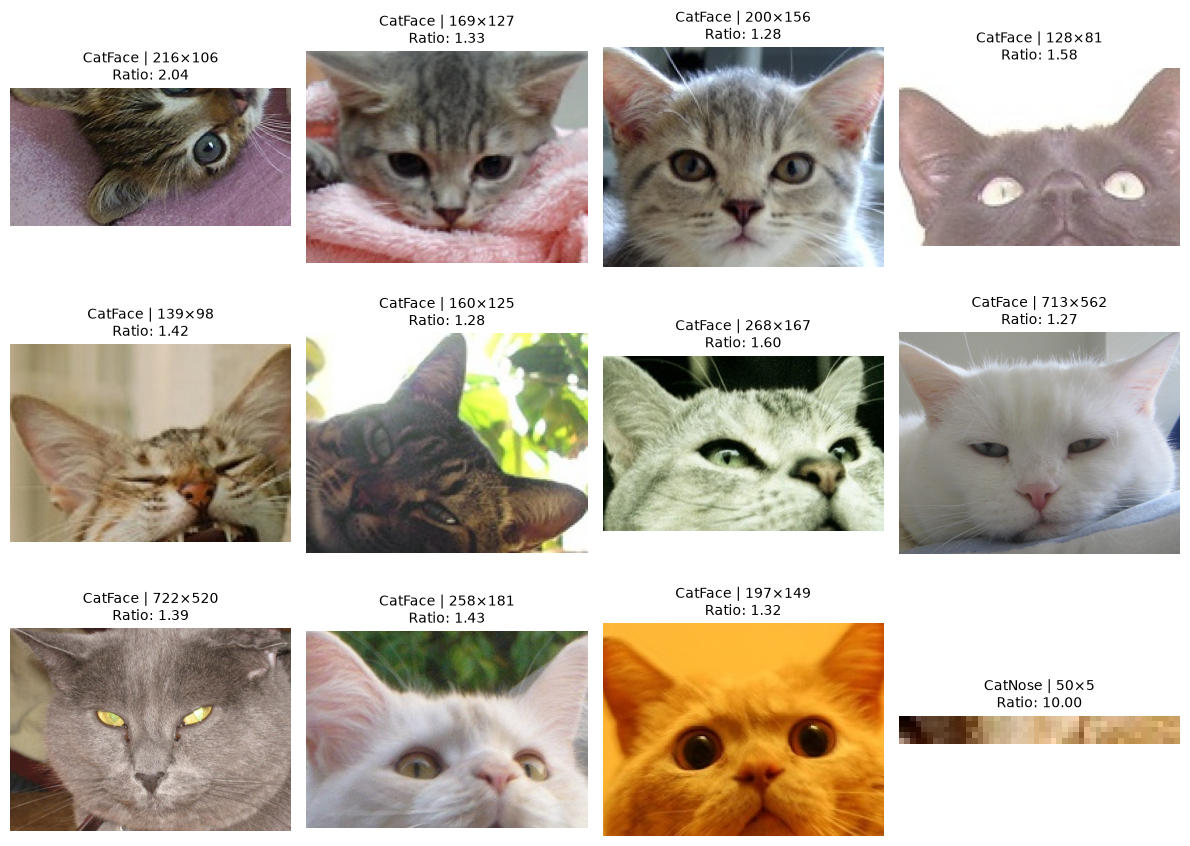

In [16]:
# Identify images that break the geometry-based rule
geometry["geometry_pred"] = geometry["ratio"] > 1.25
geometry["actual_mouth"] = geometry["class"].str.endswith("Mouth")

exceptions = geometry[
    geometry["geometry_pred"] != geometry["actual_mouth"]
]

print("Exceptions by class:")
print(exceptions["class"].value_counts())

# Display up to 12 exceptions
examples = exceptions.head(12)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flat, examples.iterrows()):
    with Image.open(TRAIN_DIR / f"{row['image_id']}.jpg") as img:
        ax.imshow(img)
        w, h = img.size

    ax.set_title(f"{row['class']} | {w}×{h}\nRatio: {row['ratio']:.2f}", fontsize=10)
    ax.axis("off")

for ax in axes.flat[len(examples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, f1_score

# Existing staged CNN predictions
actual = np.array(stage3["true"])
baseline = np.array(stage3["pred"])
hybrid = baseline.copy()

# Original image aspect ratios
ratios = []
for image_id in val_data["image_id"]:
    with Image.open(TRAIN_DIR / f"{image_id}.jpg") as img:
        ratios.append(img.width / img.height)

ratios = np.array(ratios)

# Preserve Face predictions; use geometry for other features
feature_pred = baseline % 4
wide = ratios > 1.25

change = wide & (feature_pred != 1) & (feature_pred != 2)
hybrid[change] = (baseline[change] // 4) * 4 + 2

print("Original accuracy:", f"{accuracy_score(actual, baseline):.2%}")
print("Hybrid accuracy:  ", f"{accuracy_score(actual, hybrid):.2%}")
print("Original macro F1:", f"{f1_score(actual, baseline, average='macro'):.3f}")
print("Hybrid macro F1:  ", f"{f1_score(actual, hybrid, average='macro'):.3f}")

print("\nPredictions changed:", (hybrid != baseline).sum())
print("Errors corrected:", ((baseline != actual) & (hybrid == actual)).sum())
print("New errors introduced:", ((baseline == actual) & (hybrid != actual)).sum())

print("\nHybrid classification report:")
print(classification_report(actual, hybrid, target_names=class_names, digits=3))

Original accuracy: 81.50%
Hybrid accuracy:   81.51%
Original macro F1: 0.819
Hybrid macro F1:   0.819

Predictions changed: 2
Errors corrected: 1
New errors introduced: 0

Hybrid classification report:
              precision    recall  f1-score   support

      CatEye      0.811     0.860     0.835      2777
     CatFace      0.890     0.927     0.908      1388
    CatMouth      0.956     0.996     0.976      1388
     CatNose      0.733     0.731     0.732      1389
      DogEye      0.785     0.630     0.699      2316
     DogFace      0.749     0.821     0.784      1158
    DogMouth      0.989     0.975     0.982      1158
     DogNose      0.618     0.662     0.639      1158

    accuracy                          0.815     12732
   macro avg      0.816     0.825     0.819     12732
weighted avg      0.815     0.815     0.813     12732



In [18]:
# Analyse errors from the final staged model
actual = np.array(class_names)[np.array(stage3["true"])]
predicted = np.array(class_names)[np.array(stage3["pred"])]

error_df = pd.DataFrame({
    "actual": actual,
    "predicted": predicted
})

error_df["species_ok"] = error_df["actual"].str[:3] == error_df["predicted"].str[:3]
error_df["feature_ok"] = error_df["actual"].str[3:] == error_df["predicted"].str[3:]
error_df["class_ok"] = error_df["actual"] == error_df["predicted"]

# Accuracy breakdown by actual class
results = error_df.groupby("actual").agg(
    images=("actual", "size"),
    species_accuracy=("species_ok", "mean"),
    feature_accuracy=("feature_ok", "mean"),
    overall_accuracy=("class_ok", "mean")
)

results.iloc[:, 1:] *= 100
print("Accuracy by class (%):")
print(results.round(2))

# Most frequent cat/dog mistakes
species_errors = error_df[~error_df["species_ok"]]

print("\nTotal species classification errors:", len(species_errors))
print("\nMost common species confusions:")
print(species_errors.groupby(["actual", "predicted"])
      .size().sort_values(ascending=False).head(10))

Accuracy by class (%):
          images  species_accuracy  feature_accuracy  overall_accuracy
actual                                                                
CatEye      2777             93.19             91.79             85.99
CatFace     1388             96.61             95.39             92.72
CatMouth    1388             99.71             99.93             99.64
CatNose     1389             91.00             79.19             73.07
DogEye      2316             81.82             76.30             62.95
DogFace     1158             92.31             88.34             82.12
DogMouth    1158             97.58             99.65             97.41
DogNose     1158             90.76             73.49             66.23

Total species classification errors: 1010

Most common species confusions:
actual    predicted
DogEye    CatEye       309
CatEye    DogEye       161
DogEye    CatNose       99
CatNose   DogNose       85
DogNose   CatNose       84
DogFace   CatFace       72
CatFace  

In [19]:
from torchvision.models import resnet18, ResNet18_Weights

class StagedResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Pretrained visual feature extractor
        self.encoder = resnet18(weights=ResNet18_Weights.DEFAULT)
        features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        # Independent classification heads
        self.species_head = nn.Linear(features, 2)
        self.feature_head = nn.Linear(features, 4)

        # ImageNet normalization for pretrained weights
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        features = self.encoder((x - self.mean) / self.std)
        return self.species_head(features), self.feature_head(features)

# Create a new model without changing the original
torch.manual_seed(42)
resnet_model = StagedResNet().to(device)

# Stage 1: freeze pretrained layers and train Cat/Dog recognition
resnet_model.encoder.requires_grad_(False)
resnet_model.feature_head.requires_grad_(False)

print("Total parameters:", sum(p.numel() for p in resnet_model.parameters()))
print("Trainable parameters:", sum(p.numel() for p in resnet_model.parameters() if p.requires_grad))
print("Device:", device)

0.6%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\GGPC/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Total parameters: 11179590
Trainable parameters: 1026
Device: cuda


In [20]:
# Stage 1 — Cat/Dog recognition
resnet_model.encoder.requires_grad_(False)
resnet_model.feature_head.requires_grad_(False)
resnet_model.species_head.requires_grad_(True)

optimizer_resnet = torch.optim.Adam(resnet_model.species_head.parameters(), lr=0.001)
scaler_resnet = GradScaler("cuda", enabled=device.type == "cuda")

best_species_acc = 0
history_resnet_species = []

for epoch in range(5):
    start = time.perf_counter()
    resnet_model.train()
    resnet_model.encoder.eval()  # Keep pretrained BatchNorm statistics unchanged
    train_correct = 0

    for images, species, _, _ in train_loader:
        images = images.to(device, non_blocking=True)
        species = species.to(device, non_blocking=True)

        optimizer_resnet.zero_grad(set_to_none=True)

        with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
            species_logits, _ = resnet_model(images)
            loss = criterion(species_logits, species)

        scaler_resnet.scale(loss).backward()
        scaler_resnet.step(optimizer_resnet)
        scaler_resnet.update()

        train_correct += (species_logits.argmax(1) == species).sum().item()

    # Validation
    resnet_model.eval()
    val_correct = 0

    with torch.inference_mode():
        for images, species, _, _ in val_loader:
            images = images.to(device, non_blocking=True)
            species = species.to(device, non_blocking=True)

            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                species_logits, _ = resnet_model(images)

            val_correct += (species_logits.argmax(1) == species).sum().item()

    train_acc = train_correct / len(train_data)
    val_acc = val_correct / len(val_data)
    elapsed = time.perf_counter() - start

    history_resnet_species.append((train_acc, val_acc, elapsed))

    if val_acc > best_species_acc:
        best_species_acc = val_acc
        torch.save(resnet_model.state_dict(), CHECKPOINTS / "resnet_stage1_species.pt")

    print(f"Epoch {epoch+1}/5 | Train: {train_acc:.2%} | "
          f"Validation: {val_acc:.2%} | Time: {elapsed:.1f}s")

# Restore best checkpoint before Stage 2
resnet_model.load_state_dict(torch.load(
    CHECKPOINTS / "resnet_stage1_species.pt",
    map_location=device, weights_only=True
))

print(f"\nBest ResNet Cat/Dog accuracy: {best_species_acc:.2%}")
print("Previous staged CNN: 92.07%")

Epoch 1/5 | Train: 97.49% | Validation: 98.77% | Time: 31.7s
Epoch 2/5 | Train: 98.73% | Validation: 98.77% | Time: 30.7s
Epoch 3/5 | Train: 98.89% | Validation: 98.92% | Time: 30.7s
Epoch 4/5 | Train: 98.88% | Validation: 99.00% | Time: 30.7s
Epoch 5/5 | Train: 98.98% | Validation: 98.77% | Time: 30.6s

Best ResNet Cat/Dog accuracy: 99.00%
Previous staged CNN: 92.07%


In [22]:
# Stage 2 — Train facial-feature recognition
resnet_model.encoder.requires_grad_(False)
resnet_model.species_head.requires_grad_(False)
resnet_model.feature_head.requires_grad_(True)

optimizer_feature = torch.optim.Adam(resnet_model.feature_head.parameters(), lr=0.001)
scaler_feature = GradScaler("cuda", enabled=device.type == "cuda")

best_feature_acc = 0
history_resnet_feature = []

for epoch in range(5):
    start = time.perf_counter()

    resnet_model.train()
    resnet_model.encoder.eval()
    resnet_model.species_head.eval()

    train_correct = 0

    for images, _, features, _ in train_loader:
        images = images.to(device, non_blocking=True)
        features = features.to(device, non_blocking=True)

        optimizer_feature.zero_grad(set_to_none=True)

        with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
            _, feature_logits = resnet_model(images)
            loss = criterion(feature_logits, features)

        scaler_feature.scale(loss).backward()
        scaler_feature.step(optimizer_feature)
        scaler_feature.update()

        train_correct += (feature_logits.argmax(1) == features).sum().item()

    # Validation: species, features and combined eight-class prediction
    resnet_model.eval()
    feature_correct = species_correct = combined_correct = 0

    with torch.inference_mode():
        for images, species, features, labels in val_loader:
            images = images.to(device, non_blocking=True)

            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                species_logits, feature_logits = resnet_model(images)

            sp = species_logits.argmax(1).cpu()
            ft = feature_logits.argmax(1).cpu()

            species_correct += (sp == species).sum().item()
            feature_correct += (ft == features).sum().item()
            combined_correct += (sp * 4 + ft == labels).sum().item()

    train_acc = train_correct / len(train_data)
    feature_acc = feature_correct / len(val_data)
    species_acc = species_correct / len(val_data)
    combined_acc = combined_correct / len(val_data)
    elapsed = time.perf_counter() - start

    history_resnet_feature.append((train_acc, feature_acc, combined_acc, elapsed))

    if feature_acc > best_feature_acc:
        best_feature_acc = feature_acc
        torch.save(resnet_model.state_dict(), CHECKPOINTS / "resnet_stage2_feature.pt")

    print(f"Epoch {epoch+1}/5 | Train: {train_acc:.2%} | "
          f"Feature: {feature_acc:.2%} | "
          f"Cat/Dog: {species_acc:.2%} | "
          f"8-class: {combined_acc:.2%} | Time: {elapsed:.1f}s")

# Restore best Stage 2 checkpoint
resnet_model.load_state_dict(torch.load(
    CHECKPOINTS / "resnet_stage2_feature.pt",
    map_location=device, weights_only=True
))

print(f"\nBest feature accuracy: {best_feature_acc:.2%}")
print("Previous staged CNN feature accuracy: 87.61%")

Epoch 1/5 | Train: 95.03% | Feature: 98.22% | Cat/Dog: 99.00% | 8-class: 97.38% | Time: 31.0s
Epoch 2/5 | Train: 98.27% | Feature: 98.42% | Cat/Dog: 99.00% | 8-class: 97.55% | Time: 30.9s
Epoch 3/5 | Train: 98.45% | Feature: 98.63% | Cat/Dog: 99.00% | 8-class: 97.79% | Time: 30.5s
Epoch 4/5 | Train: 98.60% | Feature: 98.62% | Cat/Dog: 99.00% | 8-class: 97.77% | Time: 30.6s
Epoch 5/5 | Train: 98.66% | Feature: 98.68% | Cat/Dog: 99.00% | 8-class: 97.82% | Time: 34.6s

Best feature accuracy: 98.68%
Previous staged CNN feature accuracy: 87.61%


In [23]:
from sklearn.metrics import f1_score

# Restore best Stage 2 model
resnet_model.load_state_dict(torch.load(
    CHECKPOINTS / "resnet_stage2_feature.pt",
    map_location=device, weights_only=True
))

# Freeze backbone except its final residual block
resnet_model.encoder.requires_grad_(False)
resnet_model.encoder.layer4.requires_grad_(True)

# Train both classification heads
resnet_model.species_head.requires_grad_(True)
resnet_model.feature_head.requires_grad_(True)

optimizer_joint = torch.optim.AdamW([
    {"params": resnet_model.encoder.layer4.parameters(), "lr": 1e-5},
    {"params": resnet_model.species_head.parameters(), "lr": 1e-4},
    {"params": resnet_model.feature_head.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

scaler_joint = GradScaler("cuda", enabled=device.type == "cuda")

# Preserve our Stage 2 result
best_joint = 0.9782
torch.save(resnet_model.state_dict(), CHECKPOINTS / "resnet_stage3_joint.pt")

for epoch in range(3):
    start = time.perf_counter()
    resnet_model.train()
    resnet_model.encoder.eval()  # Keep BatchNorm statistics fixed

    train_correct = 0

    for images, species, features, labels in train_loader:
        images = images.to(device, non_blocking=True)
        species = species.to(device, non_blocking=True)
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_joint.zero_grad(set_to_none=True)

        with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
            sp_logits, ft_logits = resnet_model(images)
            loss = criterion(sp_logits, species) + criterion(ft_logits, features)

        scaler_joint.scale(loss).backward()
        scaler_joint.step(optimizer_joint)
        scaler_joint.update()

        predictions = sp_logits.argmax(1) * 4 + ft_logits.argmax(1)
        train_correct += (predictions == labels).sum().item()

    # Validation
    resnet_model.eval()
    y_true, y_pred = [], []
    species_correct = feature_correct = 0

    with torch.inference_mode():
        for images, species, features, labels in val_loader:
            images = images.to(device, non_blocking=True)

            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                sp_logits, ft_logits = resnet_model(images)

            sp = sp_logits.argmax(1).cpu()
            ft = ft_logits.argmax(1).cpu()

            species_correct += (sp == species).sum().item()
            feature_correct += (ft == features).sum().item()

            y_true.extend(labels.tolist())
            y_pred.extend((sp * 4 + ft).tolist())

    joint_acc = sum(a == b for a, b in zip(y_true, y_pred)) / len(y_true)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    if joint_acc > best_joint:
        best_joint = joint_acc
        torch.save(resnet_model.state_dict(), CHECKPOINTS / "resnet_stage3_joint.pt")

    print(
        f"Epoch {epoch+1}/3 | "
        f"Train: {train_correct / len(train_data):.2%} | "
        f"Cat/Dog: {species_correct / len(val_data):.2%} | "
        f"Feature: {feature_correct / len(val_data):.2%} | "
        f"8-class: {joint_acc:.2%} | "
        f"Macro F1: {macro_f1:.3f} | "
        f"Time: {time.perf_counter()-start:.1f}s"
    )

print(f"\nBest validation accuracy: {best_joint:.2%}")

# Restore the best model
resnet_model.load_state_dict(torch.load(
    CHECKPOINTS / "resnet_stage3_joint.pt",
    map_location=device, weights_only=True
))

Epoch 1/3 | Train: 98.50% | Cat/Dog: 99.43% | Feature: 99.43% | 8-class: 98.91% | Macro F1: 0.990 | Time: 35.1s
Epoch 2/3 | Train: 99.52% | Cat/Dog: 99.29% | Feature: 99.38% | 8-class: 98.72% | Macro F1: 0.988 | Time: 35.0s
Epoch 3/3 | Train: 99.81% | Cat/Dog: 99.43% | Feature: 99.54% | 8-class: 98.99% | Macro F1: 0.990 | Time: 35.4s

Best validation accuracy: 98.99%


<All keys matched successfully>

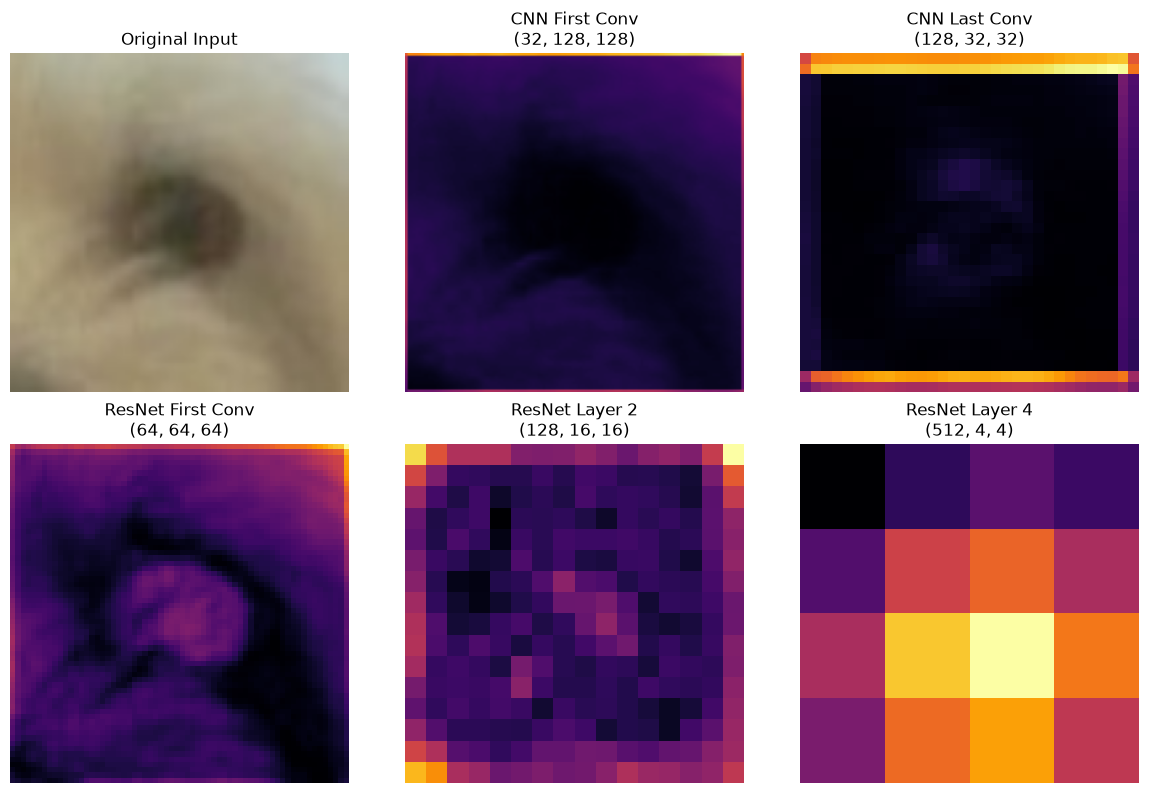

In [24]:
# Compare how the CNN and ResNet process the same image
images, _, _, _ = next(iter(val_loader))
x = images[:1].to(device)

activations = {}

def save_activation(name):
    def hook(module, inputs, output):
        activations[name] = output.detach().float().cpu()
    return hook

layers = {
    "CNN First Conv": model.encoder[0],
    "CNN Last Conv": model.encoder[6],
    "ResNet First Conv": resnet_model.encoder.conv1,
    "ResNet Layer 2": resnet_model.encoder.layer2,
    "ResNet Layer 4": resnet_model.encoder.layer4
}

hooks = [layer.register_forward_hook(save_activation(name))
         for name, layer in layers.items()]

model.eval()
resnet_model.eval()

with torch.inference_mode():
    model(x)
    resnet_model(x)

for hook in hooks:
    hook.remove()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(x[0].cpu().permute(1, 2, 0))
axes[0, 0].set_title("Original Input")

for ax, (name, activation) in zip(axes.flat[1:], activations.items()):
    heatmap = activation.abs().mean(dim=1)[0]
    ax.imshow(heatmap, cmap="inferno")
    ax.set_title(f"{name}\n{tuple(activation.shape[1:])}")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

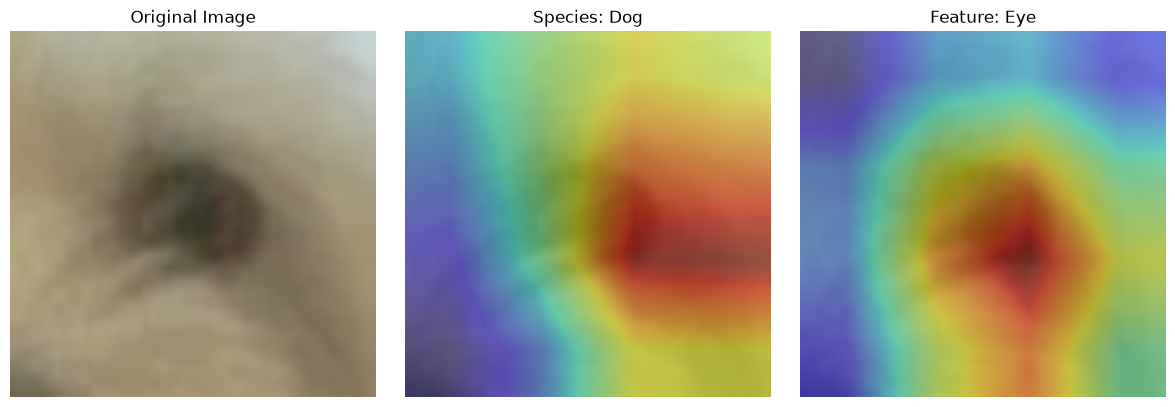

In [25]:
import torch.nn.functional as F

resnet_model.eval()
cam_features = {}

def capture_features(module, inputs, output):
    cam_features["activation"] = output

hook = resnet_model.encoder.layer4.register_forward_hook(capture_features)

# Enable gradients for this image
x_cam = x.detach().clone().to(device).requires_grad_(True)

species_logits, feature_logits = resnet_model(x_cam)
activation = cam_features["activation"]

heatmaps = []

for logits in [species_logits, feature_logits]:
    score = logits[0].max()
    gradient = torch.autograd.grad(score, activation, retain_graph=True)[0]

    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * activation).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(128, 128), mode="bilinear", align_corners=False)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
    heatmaps.append(cam[0, 0].detach().cpu())

hook.remove()

species_name = ["Cat", "Dog"][species_logits.argmax(1).item()]
feature_name = ["Eye", "Face", "Mouth", "Nose"][feature_logits.argmax(1).item()]

original = x_cam[0].detach().cpu().permute(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original)
axes[0].set_title("Original Image")

for ax, cam, title in zip(
    axes[1:], heatmaps,
    [f"Species: {species_name}", f"Feature: {feature_name}"]
):
    ax.imshow(original)
    ax.imshow(cam, cmap="jet", alpha=0.45)
    ax.set_title(title)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# Compare model architecture and trainable parameters
def count_params(module):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable

rows = []

for name, net in [("Scratch CNN", model), ("ResNet-18", resnet_model)]:
    for part, module in [
        ("Encoder", net.encoder),
        ("Species head", net.species_head),
        ("Feature head", net.feature_head),
        ("TOTAL", net)
    ]:
        total, trainable = count_params(module)
        rows.append([name, part, total, trainable])

display(pd.DataFrame(
    rows, columns=["Model", "Component", "Total Params", "Trainable Params"]
))

# Compare the layer types each architecture uses
for name, net in [("Scratch CNN", model), ("ResNet-18", resnet_model)]:
    conv = sum(isinstance(m, nn.Conv2d) for m in net.modules())
    bn = sum(isinstance(m, nn.BatchNorm2d) for m in net.modules())
    linear = sum(isinstance(m, nn.Linear) for m in net.modules())

    print(f"{name}: {conv} convolutions, {bn} BatchNorm layers, {linear} linear heads")

,Model,Component,Total Params,Trainable Params
0,Scratch CNN,Encoder,93248,93248
1,Scratch CNN,Species head,258,258
2,Scratch CNN,Feature head,516,516
3,Scratch CNN,TOTAL,94022,94022
4,ResNet-18,Encoder,11176512,8393728
5,ResNet-18,Species head,1026,1026
6,ResNet-18,Feature head,2052,2052
7,ResNet-18,TOTAL,11179590,8396806


Scratch CNN: 3 convolutions, 0 BatchNorm layers, 2 linear heads
ResNet-18: 20 convolutions, 20 BatchNorm layers, 2 linear heads


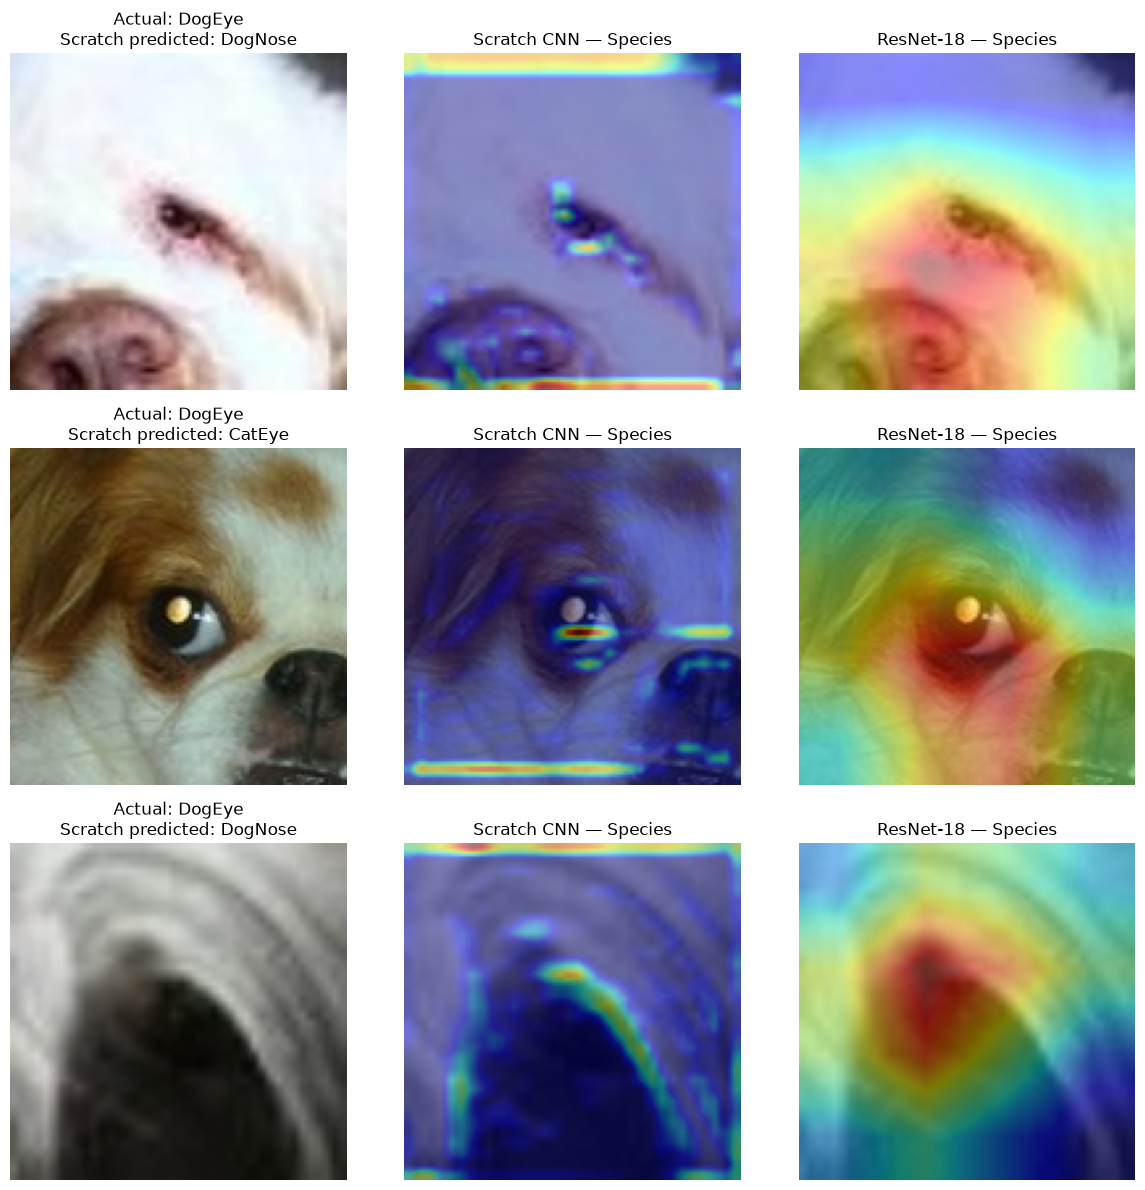

In [27]:
import torch.nn.functional as F

model.eval()
resnet_model.eval()

# Find three DogEye examples: scratch wrong, ResNet correct
examples = []
dogeye_id = class_names.index("DogEye")

with torch.inference_mode():
    for images, _, _, labels in val_loader:
        x_batch = images.to(device)

        s1, f1 = model(x_batch)
        s2, f2 = resnet_model(x_batch)

        pred_scratch = (s1.argmax(1) * 4 + f1.argmax(1)).cpu()
        pred_resnet = (s2.argmax(1) * 4 + f2.argmax(1)).cpu()

        selected = torch.where(
            (labels == dogeye_id) &
            (pred_scratch != labels) &
            (pred_resnet == labels)
        )[0]

        for i in selected.tolist():
            examples.append((images[i].clone(), class_names[pred_scratch[i].item()]))
            if len(examples) == 3:
                break

        if len(examples) == 3:
            break

# Calculate species Grad-CAM for a selected convolutional layer
def species_cam(net, layer, image):
    saved = {}
    hook = layer.register_forward_hook(
        lambda module, inputs, output: saved.update({"features": output})
    )

    try:
        x = image.unsqueeze(0).to(device).detach().requires_grad_(True)
        species_logits, _ = net(x)

        features = saved["features"]
        gradients = torch.autograd.grad(species_logits[0].max(), features)[0]

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * features).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(128, 128), mode="bilinear", align_corners=False)

        cam = cam[0, 0].detach().float().cpu()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
    finally:
        hook.remove()

# Compare identical inputs
fig, axes = plt.subplots(len(examples), 3, figsize=(12, 4 * len(examples)), squeeze=False)

for row, (image, scratch_prediction) in enumerate(examples):
    original = image.permute(1, 2, 0).numpy()

    scratch_cam = species_cam(model, model.encoder[6], image)
    resnet_cam = species_cam(resnet_model, resnet_model.encoder.layer4, image)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Actual: DogEye\nScratch predicted: {scratch_prediction}")

    for ax, cam, title in [
        (axes[row, 1], scratch_cam, "Scratch CNN — Species"),
        (axes[row, 2], resnet_cam, "ResNet-18 — Species")
    ]:
        ax.imshow(original)
        ax.imshow(cam, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        ax.set_title(title)

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

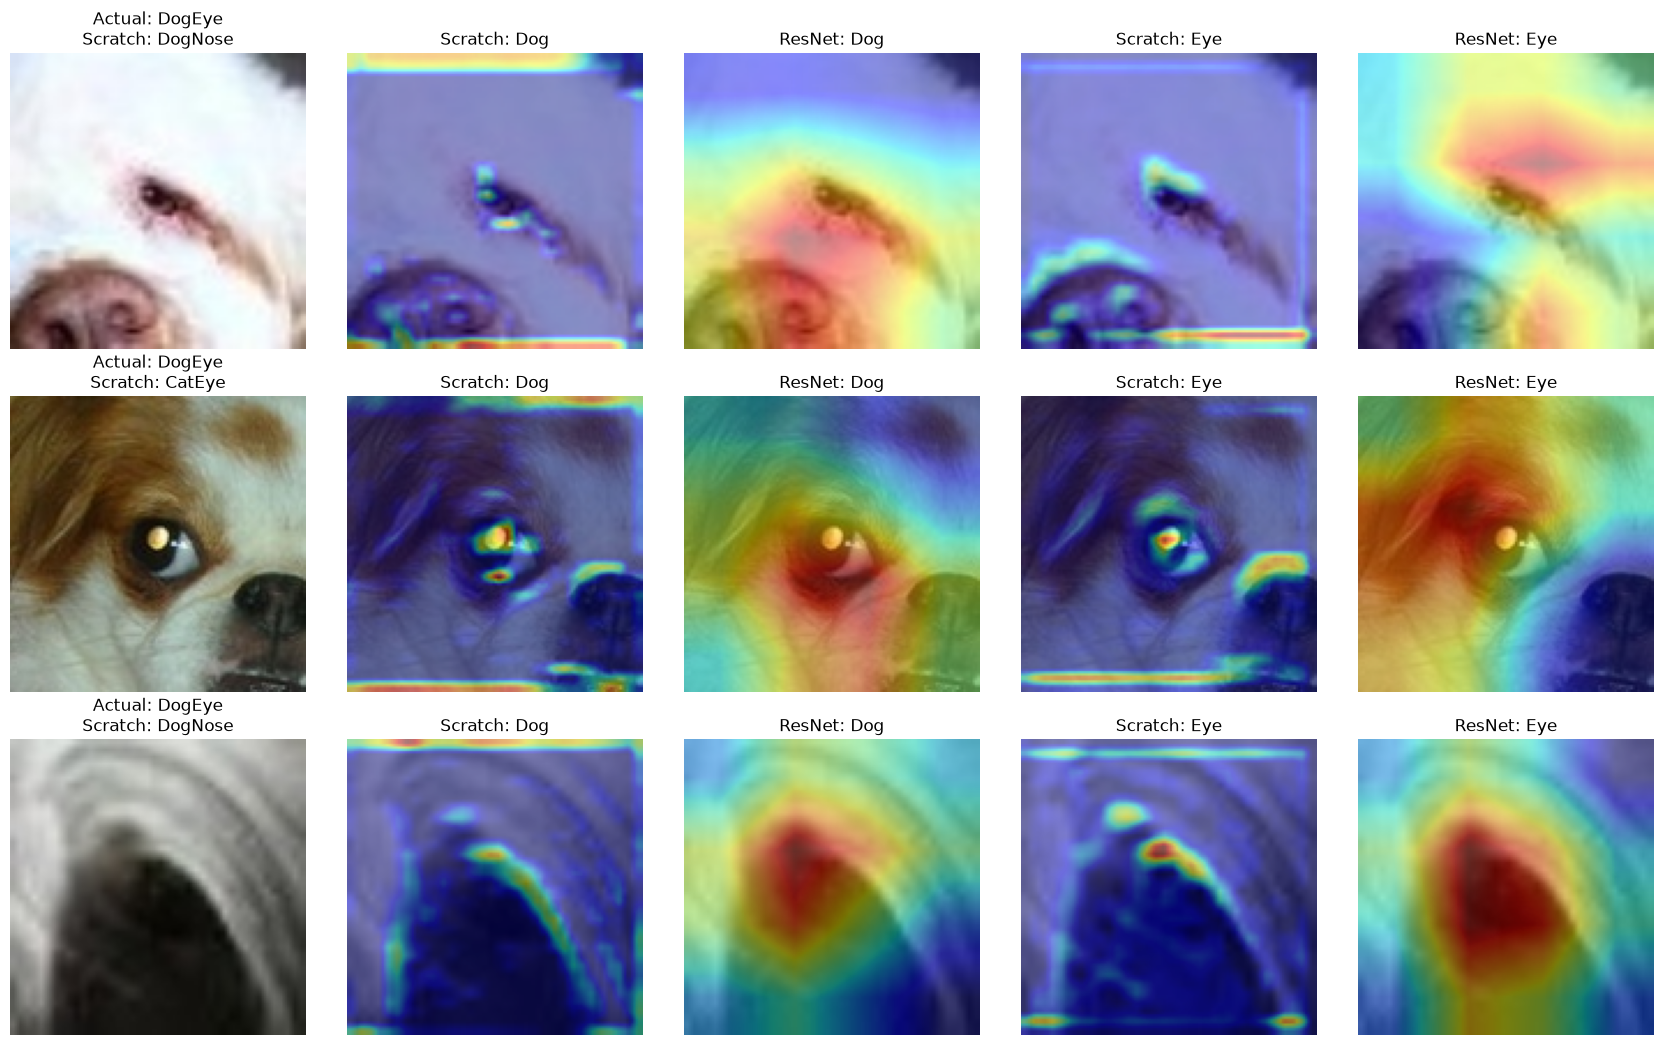

In [28]:
def target_cam(net, layer, image, head, target):
    saved = {}
    hook = layer.register_forward_hook(
        lambda m, inp, out: saved.update({"features": out})
    )

    try:
        x = image.unsqueeze(0).to(device).requires_grad_(True)
        species, feature = net(x)
        logits = species if head == "species" else feature

        activations = saved["features"]
        gradients = torch.autograd.grad(logits[0, target], activations)[0]

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=image.shape[-2:], mode="bilinear", align_corners=False)

        cam = cam[0, 0].detach().float().cpu()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
    finally:
        hook.remove()


fig, axes = plt.subplots(len(examples), 5, figsize=(17, 3.5 * len(examples)), squeeze=False)

for row, (image, prediction) in enumerate(examples):
    original = image.permute(1, 2, 0).cpu().numpy()

    settings = [
        (model, model.encoder[6], "species", 1, "Scratch: Dog"),
        (resnet_model, resnet_model.encoder.layer4, "species", 1, "ResNet: Dog"),
        (model, model.encoder[6], "feature", 0, "Scratch: Eye"),
        (resnet_model, resnet_model.encoder.layer4, "feature", 0, "ResNet: Eye")
    ]

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Actual: DogEye\nScratch: {prediction}")

    for col, (net, layer, head, target, title) in enumerate(settings, 1):
        cam = target_cam(net, layer, image, head, target)

        axes[row, col].imshow(original)
        axes[row, col].imshow(cam, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        axes[row, col].set_title(title)

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import torch
import torch.nn as nn

# Residual block with BatchNorm and skip connection
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        self.skip = (
            nn.Identity() if stride == 1 and in_channels == out_channels
            else nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.layers(x) + self.skip(x))


# New CNN trained entirely from scratch
class ScratchCNNV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            ResidualBlock(32, 32),
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 256, stride=2)
        )

        # Preserve both spatial layout and strong local responses
        self.avg_pool = nn.AdaptiveAvgPool2d((2, 2))
        self.max_pool = nn.AdaptiveMaxPool2d((1, 1))

        self.species_head = nn.Sequential(
            nn.Linear(256 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )

        self.feature_head = nn.Sequential(
            nn.Linear(256 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = torch.cat([
            self.avg_pool(x).flatten(1),
            self.max_pool(x).flatten(1)
        ], dim=1)

        return self.species_head(x), self.feature_head(x)


# Initialise a fresh model
torch.manual_seed(42)
scratch_v2 = ScratchCNNV2().to(device)

print("Total parameters:",
      sum(p.numel() for p in scratch_v2.parameters()))

print("Trainable parameters:",
      sum(p.numel() for p in scratch_v2.parameters() if p.requires_grad))

# Verify output dimensions
with torch.no_grad():
    species, features = scratch_v2.eval()(
        torch.randn(2, 3, 128, 128, device=device)
    )

print("Species output:", species.shape)
print("Feature output:", features.shape)

Total parameters: 1555110
Trainable parameters: 1555110
Species output: torch.Size([2, 2])
Feature output: torch.Size([2, 4])


In [30]:
# Scratch CNN V2 — Stage 1: Species recognition
from torch.amp import autocast, GradScaler
import time

scratch_v2.encoder.requires_grad_(True)
scratch_v2.species_head.requires_grad_(True)
scratch_v2.feature_head.requires_grad_(False)

optimizer_v2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, scratch_v2.parameters()),
    lr=0.001, weight_decay=1e-4
)

scaler_v2 = GradScaler("cuda", enabled=device.type == "cuda")
best_v2_species = 0
history_v2_species = []

for epoch in range(8):
    start = time.perf_counter()
    scratch_v2.train()
    train_correct = train_loss = 0

    for images, species, _, _ in train_loader:
        images = images.to(device, non_blocking=True)
        species = species.to(device, non_blocking=True)

        optimizer_v2.zero_grad(set_to_none=True)

        with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
            sp_logits, _ = scratch_v2(images)
            loss = criterion(sp_logits, species)

        scaler_v2.scale(loss).backward()
        scaler_v2.step(optimizer_v2)
        scaler_v2.update()

        train_correct += (sp_logits.argmax(1) == species).sum().item()
        train_loss += loss.item() * len(species)

    # Validation
    scratch_v2.eval()
    val_correct = 0

    with torch.inference_mode():
        for images, species, _, _ in val_loader:
            images = images.to(device, non_blocking=True)
            species = species.to(device, non_blocking=True)

            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                sp_logits, _ = scratch_v2(images)

            val_correct += (sp_logits.argmax(1) == species).sum().item()

    train_acc = train_correct / len(train_data)
    val_acc = val_correct / len(val_data)
    history_v2_species.append((train_acc, val_acc))

    if val_acc > best_v2_species:
        best_v2_species = val_acc
        torch.save(scratch_v2.state_dict(), CHECKPOINTS / "scratch_v2_stage1.pt")

    print(
        f"Epoch {epoch+1}/8 | "
        f"Train: {train_acc:.2%} | "
        f"Validation: {val_acc:.2%} | "
        f"Loss: {train_loss/len(train_data):.4f} | "
        f"Time: {time.perf_counter()-start:.1f}s"
    )

print(f"\nBest V2 Cat/Dog accuracy: {best_v2_species:.2%}")
print("Scratch V1: 92.07% | Pretrained ResNet: 99.00%")

# Restore the best Stage 1 weights
scratch_v2.load_state_dict(torch.load(
    CHECKPOINTS / "scratch_v2_stage1.pt",
    map_location=device, weights_only=True
))

Epoch 1/8 | Train: 86.99% | Validation: 95.49% | Loss: 0.2916 | Time: 49.8s
Epoch 2/8 | Train: 96.25% | Validation: 97.63% | Loss: 0.0999 | Time: 48.7s
Epoch 3/8 | Train: 97.46% | Validation: 97.26% | Loss: 0.0690 | Time: 48.7s
Epoch 4/8 | Train: 98.15% | Validation: 97.55% | Loss: 0.0527 | Time: 48.9s
Epoch 5/8 | Train: 98.54% | Validation: 98.28% | Loss: 0.0427 | Time: 49.1s
Epoch 6/8 | Train: 98.79% | Validation: 98.66% | Loss: 0.0347 | Time: 49.0s
Epoch 7/8 | Train: 98.94% | Validation: 98.60% | Loss: 0.0293 | Time: 49.2s
Epoch 8/8 | Train: 99.14% | Validation: 98.57% | Loss: 0.0253 | Time: 48.6s

Best V2 Cat/Dog accuracy: 98.66%
Scratch V1: 92.07% | Pretrained ResNet: 99.00%


<All keys matched successfully>

In [31]:
# Scratch CNN V2 — Stage 2: Facial-feature recognition
scratch_v2.encoder.requires_grad_(False)
scratch_v2.species_head.requires_grad_(False)
scratch_v2.feature_head.requires_grad_(True)

optimizer_v2_feature = torch.optim.AdamW(
    scratch_v2.feature_head.parameters(), lr=0.001, weight_decay=1e-4
)

scaler_v2_feature = GradScaler("cuda", enabled=device.type == "cuda")
best_v2_combined = 0
history_v2_feature = []

for epoch in range(6):
    start = time.perf_counter()

    scratch_v2.train()
    scratch_v2.encoder.eval()
    scratch_v2.species_head.eval()
    train_correct = 0

    # Train only the feature head
    for images, _, features, _ in train_loader:
        images = images.to(device, non_blocking=True)
        features = features.to(device, non_blocking=True)

        optimizer_v2_feature.zero_grad(set_to_none=True)

        with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
            _, ft_logits = scratch_v2(images)
            loss = criterion(ft_logits, features)

        scaler_v2_feature.scale(loss).backward()
        scaler_v2_feature.step(optimizer_v2_feature)
        scaler_v2_feature.update()

        train_correct += (ft_logits.argmax(1) == features).sum().item()

    # Validate both heads together
    scratch_v2.eval()
    species_correct = feature_correct = combined_correct = 0

    with torch.inference_mode():
        for images, species, features, labels in val_loader:
            images = images.to(device, non_blocking=True)

            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                sp_logits, ft_logits = scratch_v2(images)

            sp = sp_logits.argmax(1).cpu()
            ft = ft_logits.argmax(1).cpu()

            species_correct += (sp == species).sum().item()
            feature_correct += (ft == features).sum().item()
            combined_correct += (sp * 4 + ft == labels).sum().item()

    train_acc = train_correct / len(train_data)
    species_acc = species_correct / len(val_data)
    feature_acc = feature_correct / len(val_data)
    combined_acc = combined_correct / len(val_data)

    history_v2_feature.append((train_acc, species_acc, feature_acc, combined_acc))

    if combined_acc > best_v2_combined:
        best_v2_combined = combined_acc
        torch.save(scratch_v2.state_dict(), CHECKPOINTS / "scratch_v2_stage2.pt")

    print(
        f"Epoch {epoch+1}/6 | Train: {train_acc:.2%} | "
        f"Cat/Dog: {species_acc:.2%} | Feature: {feature_acc:.2%} | "
        f"8-class: {combined_acc:.2%} | Time: {time.perf_counter()-start:.1f}s"
    )

print(f"\nBest V2 eight-class accuracy: {best_v2_combined:.2%}")

scratch_v2.load_state_dict(torch.load(
    CHECKPOINTS / "scratch_v2_stage2.pt",
    map_location=device, weights_only=True
))

Epoch 1/6 | Train: 87.63% | Cat/Dog: 98.66% | Feature: 91.75% | 8-class: 90.85% | Time: 30.9s
Epoch 2/6 | Train: 94.05% | Cat/Dog: 98.66% | Feature: 95.88% | 8-class: 94.86% | Time: 30.7s
Epoch 3/6 | Train: 94.96% | Cat/Dog: 98.66% | Feature: 95.75% | 8-class: 94.72% | Time: 30.8s
Epoch 4/6 | Train: 95.34% | Cat/Dog: 98.66% | Feature: 96.77% | 8-class: 95.71% | Time: 30.6s
Epoch 5/6 | Train: 95.63% | Cat/Dog: 98.66% | Feature: 96.71% | 8-class: 95.69% | Time: 30.7s
Epoch 6/6 | Train: 95.82% | Cat/Dog: 98.66% | Feature: 96.69% | 8-class: 95.63% | Time: 30.5s

Best V2 eight-class accuracy: 95.71%


<All keys matched successfully>

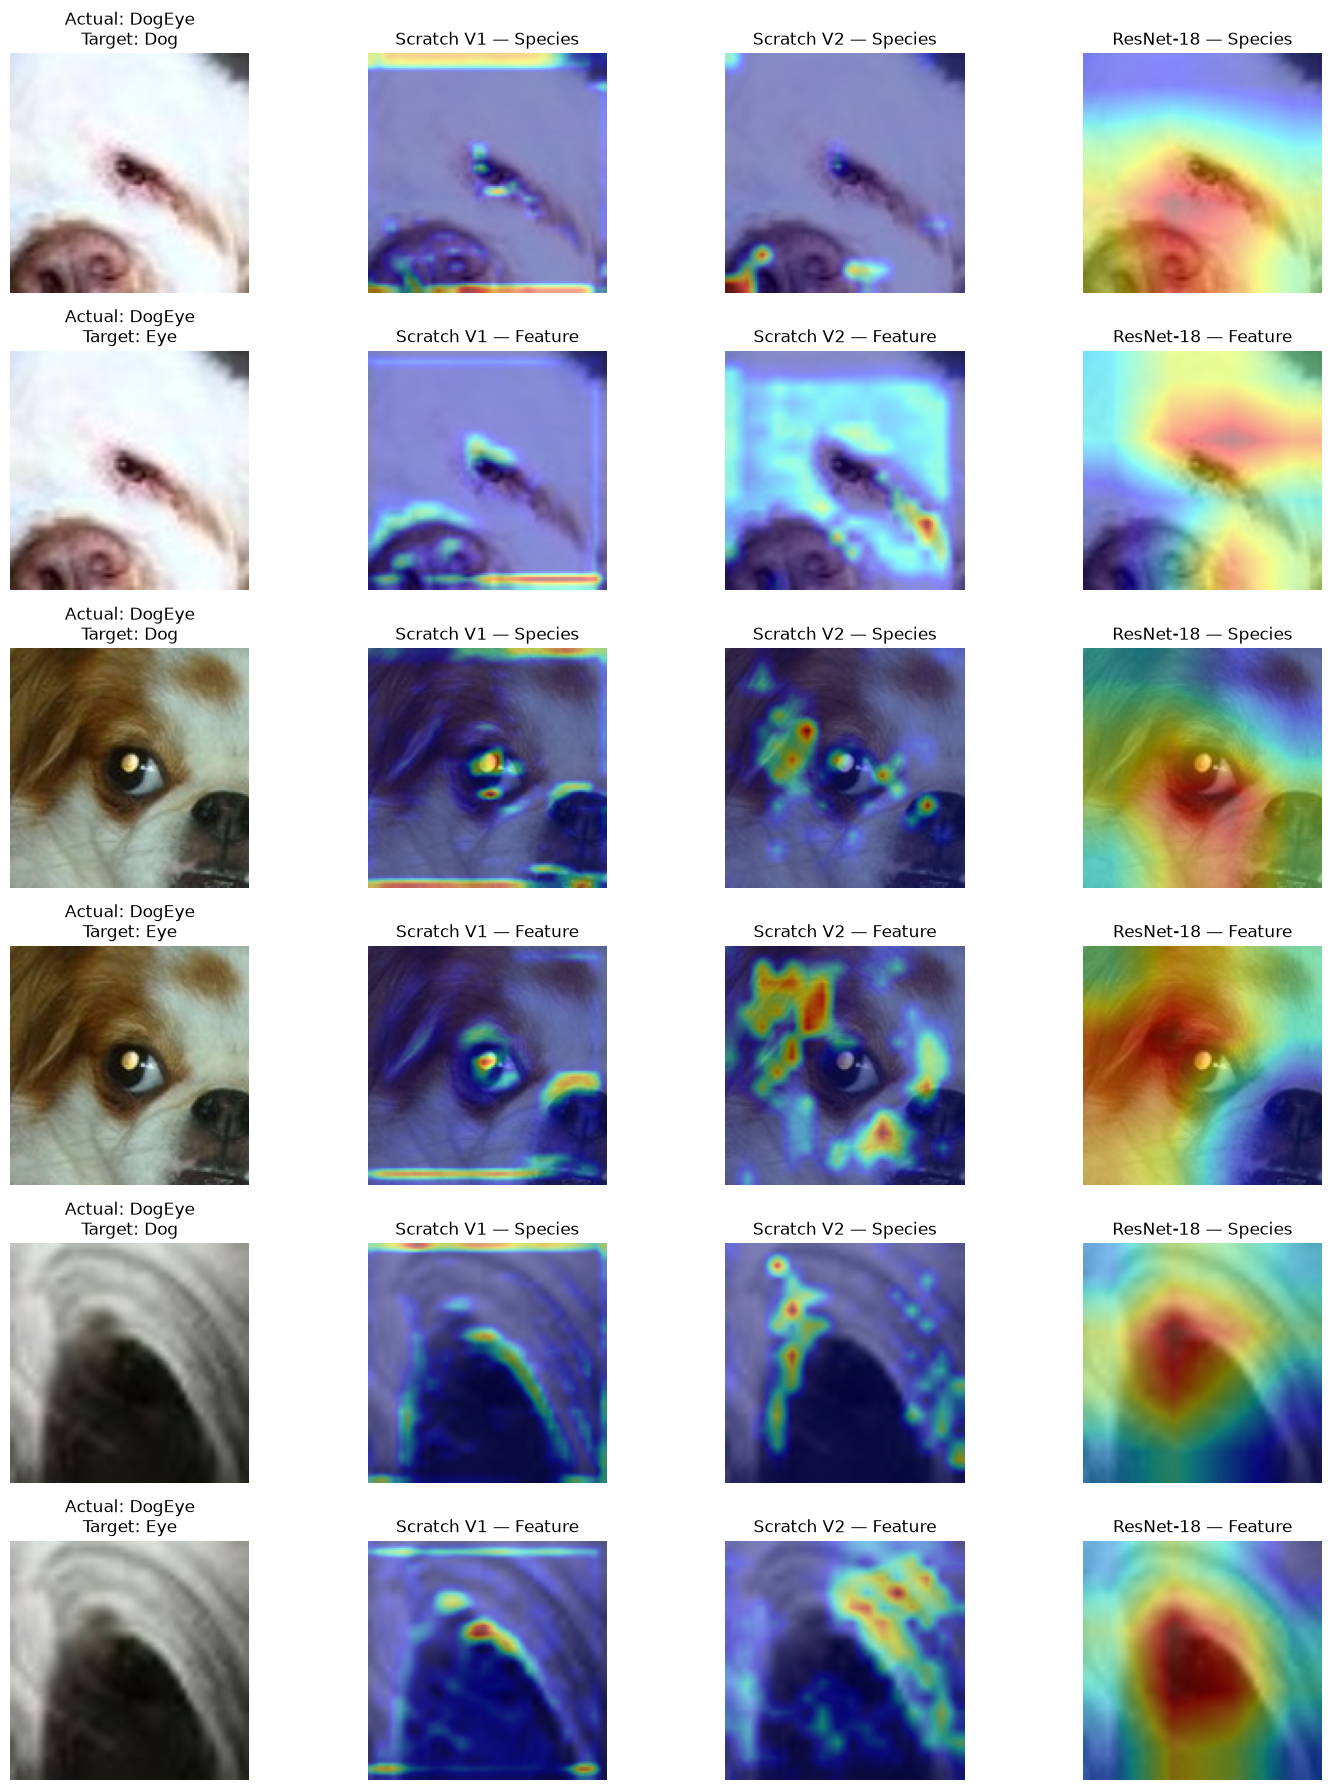

In [32]:
# Compare Grad-CAM across all three models
model.eval()
scratch_v2.eval()
resnet_model.eval()

models = [
    ("Scratch V1", model, model.encoder[6]),
    ("Scratch V2", scratch_v2, scratch_v2.encoder[-1]),
    ("ResNet-18", resnet_model, resnet_model.encoder.layer4)
]

fig, axes = plt.subplots(len(examples) * 2, 4,
                         figsize=(15, 6 * len(examples)), squeeze=False)

for i, (image, old_prediction) in enumerate(examples):
    original = image.permute(1, 2, 0).cpu().numpy()

    for j, (head, target) in enumerate([("species", 1), ("feature", 0)]):
        row = i * 2 + j

        axes[row, 0].imshow(original)
        axes[row, 0].set_title(f"Actual: DogEye\nTarget: {'Dog' if j == 0 else 'Eye'}")

        for col, (name, net, layer) in enumerate(models, start=1):
            cam = target_cam(net, layer, image, head, target)

            axes[row, col].imshow(original)
            axes[row, col].imshow(cam, cmap="jet", alpha=0.45, vmin=0, vmax=1)
            axes[row, col].set_title(f"{name} — {head.title()}")

        for ax in axes[row]:
            ax.axis("off")

plt.tight_layout()
plt.show()